# Three-phase wellstream shutdown cooldown and OpenFOAM dead-leg handoff

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/flowassurance/wellstream_shutdown_cooldown_to_openfoam_deadleg.ipynb)

This advanced demonstration asks one operational question: **after production stops, how long does a typical subsea gas–oil–water flowline remain above the hydrate-management limit?** It uses the native NeqSim `TwoFluidPipe` for the flowing initialization and closed-boundary transient, the SRK-CPA hydrate equilibrium calculation, and a native lumped SURF analyzer as an independent screen. It then packages the parent-pipe state history needed to start a local OpenFOAM dead-leg calculation.

The notebook is a demonstration, not a design or operating procedure. Replace the synthetic fluid, terrain, insulation, heat-transfer assumptions, hydrate margin, inhibitor/salinity model, and validation basis before using the workflow on an asset.

## Learning outcomes

- build and verify a gas–oil–water wellstream with SRK-CPA;
- initialize a terrain-following two-fluid flowline at production conditions;
- close both ends and retain fluid, steel, coating, and insulation thermal inertia;
- calculate the first axial location and interpolated time at which the hydrate-management margin is exhausted;
- check time-step sensitivity, mass closure, thermal-energy closure, and a native lumped cooldown screen;
- export traceable, unit-labelled boundary and initial-condition files for a tee plus dead-leg CFD domain.

## 1. Model boundary and decision metric

The one-dimensional model owns the complete flowline and the long-time shutdown history. At each axial cell, the demonstration evaluates

$$M_i(t)=T_i(t)-T_{hyd}\left(P_i(t),\mathbf{z}\right)-\Delta T_{safe}$$

and defines the **no-touch time** as

$$t_{NT}=\inf\left\{t\geq0:\min_i M_i(t)\leq0\right\}.$$

Here $T_{hyd}$ is equilibrium hydrate temperature for the same SRK-CPA composition, and $\Delta T_{safe}=3\ \mathrm{K}$ is a demonstration management margin. This is deliberately more conservative than waiting for predicted hydrate formation or plugging kinetics.

The later CFD domain should contain a short parent-pipe section, tee, and capped branch. NeqSim supplies the slow, system-scale boundary history; OpenFOAM resolves local buoyancy, stratification, recirculation, conjugate wall conduction, and cold spots that a one-dimensional cell cannot represent.

## 2. Reproducible NeqSim source runtime

In Colab, this cell checks out and builds the requested NeqSim Java source before the JVM starts. The validation path may provide an already-built JAR and a directory containing exact current-source class overlays. Both paths record the source commit, JAR SHA-256, Java version, and class code source.

In [1]:
import hashlib
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile

NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-source"))
source_jar_override = os.environ.get("NEQSIM_SOURCE_JAR")
class_overlay = os.environ.get("NEQSIM_CLASS_OVERLAY")

if source_jar_override:
    neqsim_jar = Path(source_jar_override).resolve()
    source_commit = subprocess.check_output(
        ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
    ).strip()
else:
    if not source_root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", NEQSIM_SOURCE_REF,
             NEQSIM_SOURCE_REPOSITORY, str(source_root)], check=True
        )
    else:
        subprocess.run(["git", "-C", str(source_root), "fetch", "origin", NEQSIM_SOURCE_REF], check=True)
        subprocess.run(["git", "-C", str(source_root), "checkout", "--detach", "FETCH_HEAD"], check=True)
    source_commit = subprocess.check_output(
        ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
    ).strip()
    subprocess.run(
        [str(source_root / "mvnw"), "-q", "-DskipTests", "package"],
        cwd=source_root, check=True,
    )
    candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
    candidates = [p for p in candidates if "sources" not in p.name and "javadoc" not in p.name]
    if not candidates:
        raise FileNotFoundError("NeqSim source build produced no runtime JAR")
    neqsim_jar = candidates[-1].resolve()

jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

import jpype
import jpype.imports

if class_overlay:
    jpype.addClassPath(str(Path(class_overlay).resolve()))
jpype.addClassPath(str(neqsim_jar))
if not jpype.isJVMStarted():
    jpype.startJVM(convertStrings=False)

from jpype import JArray, JClass, JDouble

TwoFluidPipe = JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
TPflash = JClass("neqsim.thermodynamicoperations.flashops.TPflash")
SurfCooldownAnalyzer = JClass("neqsim.pvtsimulation.flowassurance.SurfCooldownAnalyzer")

def class_source(java_class):
    return str(java_class.class_.getProtectionDomain().getCodeSource().getLocation())

provenance = {
    "neqsim_repository": NEQSIM_SOURCE_REPOSITORY,
    "neqsim_ref": NEQSIM_SOURCE_REF,
    "neqsim_commit": source_commit,
    "neqsim_jar": str(neqsim_jar),
    "neqsim_jar_sha256": jar_sha256,
    "TwoFluidPipe_code_source": class_source(TwoFluidPipe),
    "TPflash_code_source": class_source(TPflash),
    "SurfCooldownAnalyzer_code_source": class_source(SurfCooldownAnalyzer),
    "java_version": str(JClass("java.lang.System").getProperty("java.version")),
    "python_version": sys.version.split()[0],
}
print(json.dumps(provenance, indent=2))
assert source_commit == subprocess.check_output(
    ["git", "-C", str(source_root), "rev-parse", "HEAD"], text=True
).strip()
if class_overlay:
    assert all(class_source(c).startswith("file:") and "neqsim-current-classes" in class_source(c)
               for c in (TwoFluidPipe, TPflash, SurfCooldownAnalyzer))
else:
    assert all(neqsim_jar.name in class_source(c) for c in (TwoFluidPipe, TPflash, SurfCooldownAnalyzer))

{
  "neqsim_repository": "https://github.com/equinor/neqsim.git",
  "neqsim_ref": "master",
  "neqsim_commit": "879eeded80135ad485de4327907fe6c3282cba08",
  "neqsim_jar": "/tmp/neqsim-java/neqsim-3.17.0.jar",
  "neqsim_jar_sha256": "5c2c874f8bad73f309a73c7a35659d35388c45daa621304ef49972202ecf9443",
  "TwoFluidPipe_code_source": "file:/tmp/neqsim-current-classes/",
  "TPflash_code_source": "file:/tmp/neqsim-current-classes/",
  "SurfCooldownAnalyzer_code_source": "file:/tmp/neqsim-current-classes/",
  "java_version": "17.0.19",
  "python_version": "3.12.13"
}


In [2]:
import math
import tempfile
import time
import uuid

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5.6), "axes.titlesize": 12, "axes.labelsize": 10})

SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
ThermodynamicOperations = JClass("neqsim.thermodynamicoperations.ThermodynamicOperations")
Stream = JClass("neqsim.process.equipment.stream.Stream")
MaterialType = JClass("neqsim.process.equipment.pipeline.RadialThermalLayer$MaterialType")
MassPhase = JClass("neqsim.process.equipment.pipeline.TwoFluidMassBalanceReport$Phase")

CASE = {
    "length_m": 12_000.0,
    "diameter_m": 0.254,
    "roughness_m": 4.5e-5,
    "sections": 6,
    "elevation_m": [0.0, -20.0, -50.0, -30.0, -10.0, 0.0],
    "inlet_temperature_C": 55.0,
    "inlet_pressure_bara": 120.0,
    "outlet_pressure_bara": 95.0,
    "mass_rate_kg_s": 25.0,
    "flowing_U_W_m2K": 0.8,
    "ambient_C": 4.0,
    "wall_thickness_m": 0.0159,
    "insulation_thickness_m": 0.060,
    "closed_inner_htc_W_m2K": 50.0,
    "hydrate_safety_margin_K": 3.0,
    "fine_dt_s": 900.0,
    "coarse_dt_s": 1800.0,
    "horizon_h": 18.0,
}

COMPOSITION = {
    "nitrogen": 1.0, "CO2": 2.0, "methane": 60.0, "ethane": 8.0,
    "propane": 5.0, "i-butane": 2.0, "n-butane": 3.0,
    "i-pentane": 2.0, "n-pentane": 3.0, "n-hexane": 2.5,
    "n-heptane": 2.5, "n-octane": 1.5, "nC10": 1.0, "water": 3.5,
}

case_table = pd.DataFrame({"parameter": CASE.keys(), "value": CASE.values()})
composition_table = pd.DataFrame({
    "component": COMPOSITION.keys(),
    "mole_percent": 100.0 * np.array(list(COMPOSITION.values())) / sum(COMPOSITION.values()),
})
display(case_table)
display(composition_table.round(4))

,parameter,value
0,length_m,12000.0
1,diameter_m,0.254
2,roughness_m,0.000045
3,sections,6
4,elevation_m,"[0.0, -20.0, -50.0, -30.0, -10.0, 0.0]"
5,inlet_temperature_C,55.0
6,inlet_pressure_bara,120.0
7,outlet_pressure_bara,95.0
8,mass_rate_kg_s,25.0
9,flowing_U_W_m2K,0.8


,component,mole_percent
0,nitrogen,1.0309
1,CO2,2.0619
2,methane,61.8557
3,ethane,8.2474
4,propane,5.1546
5,i-butane,2.0619
6,n-butane,3.0928
7,i-pentane,2.0619
8,n-pentane,3.0928
9,n-hexane,2.5773


## 3. Gas–oil–water fluid and hydrate boundary

The synthetic composition represents a rich, water-bearing wellstream rather than a sales gas. SRK-CPA is used because association and a distinct aqueous phase matter to this workflow. The phase split is checked before any pipe calculation.

,phase,moles_fraction,density_kg_m3,viscosity_mPa_s
0,gas,0.62478,125.57238,0.01719
1,oil,0.34071,484.76240,0.09541
2,aqueous,0.03451,988.37983,0.50613


,pressure_bara,hydrate_equilibrium_C,management_limit_C
0,70.0,18.333,21.333
1,80.0,19.084,22.084
2,90.0,19.711,22.711
3,100.0,20.241,23.241
4,110.0,20.695,23.695
5,120.0,21.089,24.089


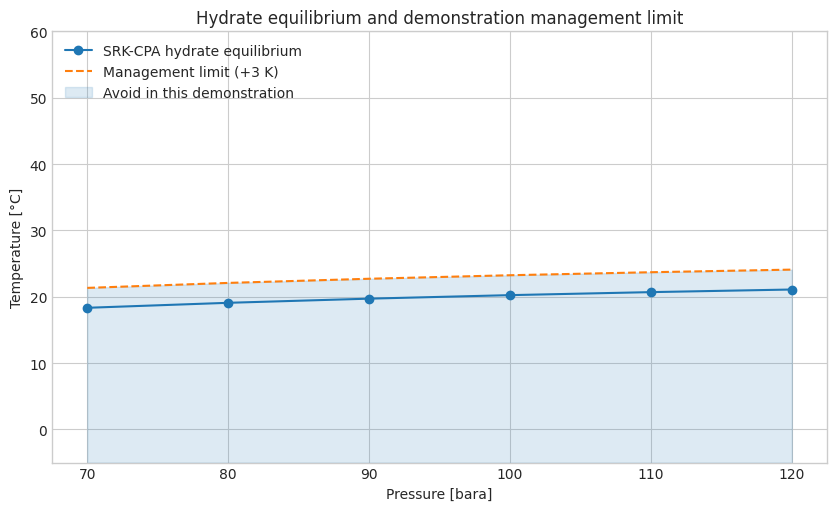

At 95–120 bara, the equilibrium curve spans **19.7–21.1 °C**. The calculation will therefore stop counting safe time 3 K above equilibrium, before entering the shaded region.

In [3]:
def build_fluid(temperature_C=CASE["inlet_temperature_C"],
                pressure_bara=CASE["inlet_pressure_bara"],
                flow_kg_s=CASE["mass_rate_kg_s"]):
    fluid = SystemSrkCPA(temperature_C + 273.15, pressure_bara)
    for name, amount in COMPOSITION.items():
        fluid.addComponent(name, float(amount))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(float(flow_kg_s), "kg/sec")
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()
    return fluid

feed_fluid = build_fluid()
phase_rows = []
for i in range(feed_fluid.getNumberOfPhases()):
    phase = feed_fluid.getPhase(i)
    phase_rows.append({
        "phase": str(phase.getPhaseTypeName()),
        "moles_fraction": float(phase.getBeta()),
        "density_kg_m3": float(phase.getDensity("kg/m3")),
        "viscosity_mPa_s": 1000.0 * float(phase.getViscosity("kg/msec")),
    })
phase_table = pd.DataFrame(phase_rows)
display(phase_table.round(5))
phase_names = {name.lower() for name in phase_table["phase"]}
assert {"gas", "oil", "aqueous"}.issubset(phase_names), phase_names

hydrate_cache = {}
def hydrate_temperature_C(pressure_bara):
    key = round(float(pressure_bara), 4)
    if key not in hydrate_cache:
        fluid = SystemSrkCPA(283.15, key)
        for name, amount in COMPOSITION.items():
            fluid.addComponent(name, float(amount))
        fluid.setMixingRule(10)
        fluid.setHydrateCheck(True)
        ThermodynamicOperations(fluid).hydrateFormationTemperature()
        hydrate_cache[key] = float(fluid.getTemperature("C"))
    return hydrate_cache[key]

hydrate_pressure_bara = np.arange(70.0, 121.0, 10.0)
hydrate_temperature_curve_C = np.array(
    [hydrate_temperature_C(p) for p in hydrate_pressure_bara]
)
hydrate_table = pd.DataFrame({
    "pressure_bara": hydrate_pressure_bara,
    "hydrate_equilibrium_C": hydrate_temperature_curve_C,
    "management_limit_C": hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
})
display(hydrate_table.round(3))

fig, ax = plt.subplots()
ax.plot(hydrate_pressure_bara, hydrate_temperature_curve_C, "o-", label="SRK-CPA hydrate equilibrium")
ax.plot(hydrate_pressure_bara, hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
        "--", label="Management limit (+3 K)")
ax.fill_between(hydrate_pressure_bara, -5.0,
                hydrate_temperature_curve_C + CASE["hydrate_safety_margin_K"],
                alpha=0.15, color="tab:blue", label="Avoid in this demonstration")
ax.set(xlabel="Pressure [bara]", ylabel="Temperature [°C]", ylim=(-5, 60),
       title="Hydrate equilibrium and demonstration management limit")
ax.legend(loc="upper left")
plt.show()
display(Markdown(
    f"At 95–120 bara, the equilibrium curve spans **{hydrate_temperature_curve_C[2]:.1f}–"
    f"{hydrate_temperature_curve_C[-1]:.1f} °C**. The calculation will therefore stop counting safe time "
    "3 K above equilibrium, before entering the shaded region."
))

## 4. Flowing two-fluid initialization

The six finite-volume cells are intentionally coarse enough to keep the demonstration quick while retaining terrain-induced inventory differences. A 25 kg/s wellstream enters at 55 °C and 120 bara; the outlet pressure is fixed at 95 bara. A simple flowing U-value initializes the axial thermal state. Shutdown then replaces this with the radial steel/FBE/PU-foam thermal model.

,x_km,elevation_m,pressure_bara,temperature_C,gas_holdup,oil_holdup,water_holdup,hydrate_equilibrium_C,hydrate_margin_K
0,1.0,0.0,97.3532,55.0000,0.0500,0.9329,0.0171,20.1008,31.8992
1,3.0,-20.0,98.6886,54.1117,0.5068,0.4835,0.0097,20.1716,30.9400
2,5.0,-50.0,97.4621,53.2388,0.1500,0.8280,0.0220,20.1066,30.1322
3,7.0,-30.0,96.4276,52.3812,0.5114,0.4749,0.0137,20.0518,29.3294
4,9.0,-10.0,95.8646,51.5384,0.5100,0.4750,0.0150,20.0219,28.5165
5,11.0,0.0,95.0000,50.7104,0.5109,0.4729,0.0162,19.9761,27.7343


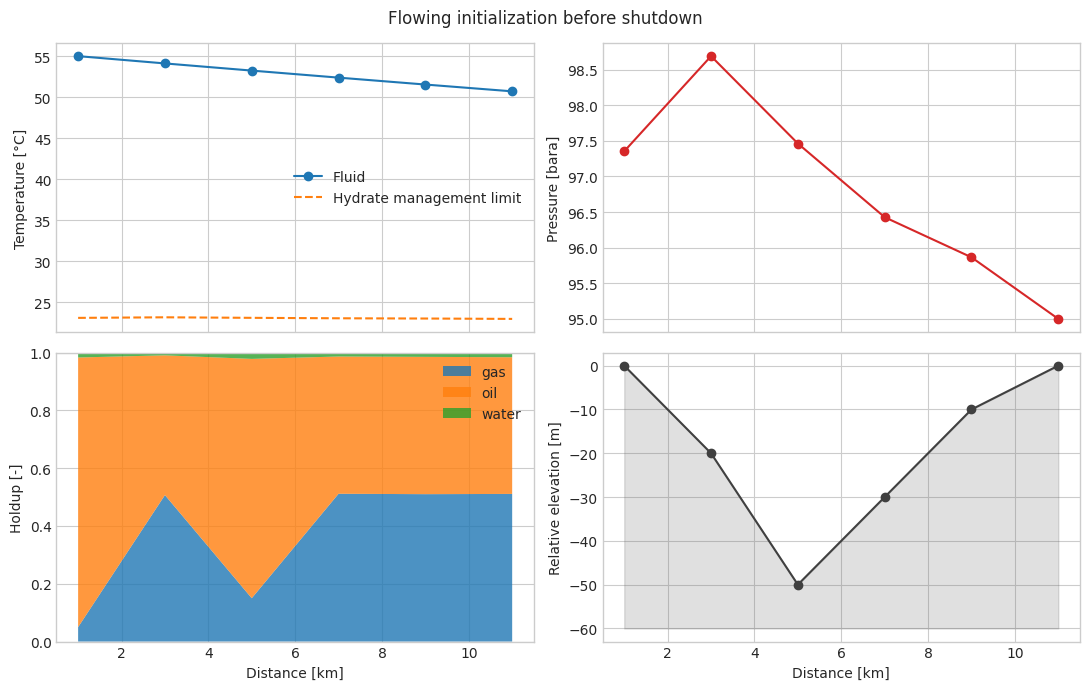

The flowing state cools from **55.0 to 50.7 °C**. Its minimum management margin is **27.7 K**. The terrain and holdup panels identify why the first unsafe point need not be the outlet.

In [4]:
def build_flowing_pipe():
    inlet = Stream("three-phase wellstream", build_fluid())
    inlet.setFlowRate(CASE["mass_rate_kg_s"], "kg/sec")
    inlet.setTemperature(CASE["inlet_temperature_C"], "C")
    inlet.setPressure(CASE["inlet_pressure_bara"], "bara")
    inlet.run()

    pipe = TwoFluidPipe("12 km shutdown cooldown demonstration", inlet)
    pipe.setLength(CASE["length_m"])
    pipe.setDiameter(CASE["diameter_m"])
    pipe.setRoughness(CASE["roughness_m"])
    pipe.setNumberOfSections(CASE["sections"])
    pipe.setElevationProfile(JArray(JDouble)(CASE["elevation_m"]))
    pipe.setEnableTerrainTracking(True)
    pipe.setOutletPressure(CASE["outlet_pressure_bara"], "bara")
    pipe.setIncludeEnergyEquation(True)
    pipe.setSurfaceTemperature(CASE["ambient_C"], "C")
    pipe.setHeatTransferCoefficient(CASE["flowing_U_W_m2K"])
    pipe.setThermodynamicUpdateInterval(8)
    pipe.setSteadyStateFlashInterval(8)
    pipe.setSteadyStateMaxWallClockTime(90.0)
    pipe.run()
    return inlet, pipe

steady_started = time.monotonic()
steady_inlet, steady_pipe = build_flowing_pipe()
steady_elapsed_s = time.monotonic() - steady_started

x_m = np.asarray(steady_pipe.getPositionProfile(), dtype=float)
steady = pd.DataFrame({
    "x_km": x_m / 1000.0,
    "elevation_m": CASE["elevation_m"],
    "pressure_bara": np.asarray(steady_pipe.getPressureProfile(), dtype=float) / 1e5,
    "temperature_C": np.asarray(steady_pipe.getTemperatureProfile("C"), dtype=float),
    "gas_holdup": 1.0 - np.asarray(steady_pipe.getLiquidHoldupProfile(), dtype=float),
    "oil_holdup": np.asarray(steady_pipe.getOilHoldupProfile(), dtype=float),
    "water_holdup": np.asarray(steady_pipe.getWaterHoldupProfile(), dtype=float),
})
steady["hydrate_equilibrium_C"] = np.interp(
    steady["pressure_bara"], hydrate_pressure_bara, hydrate_temperature_curve_C
)
steady["hydrate_margin_K"] = (
    steady["temperature_C"] - steady["hydrate_equilibrium_C"]
    - CASE["hydrate_safety_margin_K"]
)
display(steady.round(4))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
axes[0, 0].plot(steady.x_km, steady.temperature_C, "o-", label="Fluid")
axes[0, 0].plot(steady.x_km, steady.hydrate_equilibrium_C + CASE["hydrate_safety_margin_K"],
                "--", label="Hydrate management limit")
axes[0, 0].set_ylabel("Temperature [°C]"); axes[0, 0].legend()
axes[0, 1].plot(steady.x_km, steady.pressure_bara, "o-", color="tab:red")
axes[0, 1].set_ylabel("Pressure [bara]")
axes[1, 0].stackplot(steady.x_km, steady.gas_holdup, steady.oil_holdup, steady.water_holdup,
                     labels=["gas", "oil", "water"], alpha=0.8)
axes[1, 0].set(xlabel="Distance [km]", ylabel="Holdup [-]", ylim=(0, 1)); axes[1, 0].legend(loc="upper right")
axes[1, 1].plot(steady.x_km, steady.elevation_m, "o-", color="0.25")
axes[1, 1].fill_between(steady.x_km, steady.elevation_m, min(steady.elevation_m)-10, alpha=0.2, color="0.4")
axes[1, 1].set(xlabel="Distance [km]", ylabel="Relative elevation [m]")
fig.suptitle("Flowing initialization before shutdown")
fig.tight_layout()
plt.show()
display(Markdown(
    f"The flowing state cools from **{steady.temperature_C.iloc[0]:.1f} to {steady.temperature_C.iloc[-1]:.1f} °C**. "
    f"Its minimum management margin is **{steady.hydrate_margin_K.min():.1f} K**. "
    "The terrain and holdup panels identify why the first unsafe point need not be the outlet."
))

## 5. Close-in transient with radial thermal inertia

Both external mass-flow faces are closed. NeqSim retains local gas, oil, and water inventories, updates the three-phase two-fluid state, and exchanges heat in every cell with cell-owned radial layer temperatures. The closed-flow fluid-side coefficient is set explicitly to 50 W/(m² K); the radial calculator separately represents steel, FBE, and 60 mm PU foam. This avoids treating the insulation-level overall U-value as a second fluid-film coefficient.

The base run uses 15-minute macro steps for 18 hours. Hydrate equilibrium is interpolated from the SRK-CPA pressure grid at every cell and time step.

In [5]:
def configure_shutdown(pipe):
    pipe.setWallProperties(CASE["wall_thickness_m"], 7850.0, 480.0)
    pipe.setSurfaceTemperature(CASE["ambient_C"], "C")
    pipe.configureSubseaThermalModel(
        CASE["insulation_thickness_m"], 0.0, MaterialType.PU_FOAM
    )
    calculator = pipe.getThermalCalculator()
    calculator.setFluidTemperature(float(np.mean(pipe.getTemperatureProfile())))
    calculator.setAmbientTemperature(CASE["ambient_C"] + 273.15)
    calculator.initializeLayerTemperaturesLinear()
    radial_overall_U = float(calculator.calculateOverallUValue())
    pipe.setHeatTransferCoefficient(CASE["closed_inner_htc_W_m2K"])
    pipe.setIncludeMassTransfer(False)
    pipe.setComponentTransportEnabled(False)
    pipe.setEnableJouleThomson(False)
    pipe.setEnableAdaptiveTimestepping(False)
    pipe.setThermodynamicUpdateInterval(1_000_000)
    pipe.closeInlet()
    pipe.closeOutlet()
    return radial_overall_U

def local_record(pipe, time_s, mass0_kg):
    p_bara = np.asarray(pipe.getPressureProfile(), dtype=float) / 1e5
    T_C = np.asarray(pipe.getTemperatureProfile("C"), dtype=float)
    alpha_o = np.asarray(pipe.getOilHoldupProfile(), dtype=float)
    alpha_w = np.asarray(pipe.getWaterHoldupProfile(), dtype=float)
    alpha_g = 1.0 - np.asarray(pipe.getLiquidHoldupProfile(), dtype=float)
    T_hyd_C = np.interp(p_bara, hydrate_pressure_bara, hydrate_temperature_curve_C)
    margin_K = T_C - T_hyd_C - CASE["hydrate_safety_margin_K"]
    mass_report = pipe.getLastMassBalanceReport() if time_s > 0 else None
    thermal_report = pipe.getLastThermalEnergyBalanceReport() if time_s > 0 else None
    rows = []
    for i in range(CASE["sections"]):
        rows.append({
            "time_s": time_s, "time_h": time_s / 3600.0, "cell": i,
            "x_m": x_m[i], "elevation_m": CASE["elevation_m"][i],
            "pressure_Pa": p_bara[i] * 1e5, "pressure_bara": p_bara[i],
            "temperature_K": T_C[i] + 273.15, "temperature_C": T_C[i],
            "wall_temperature_K": float(np.asarray(pipe.getWallTemperatureProfile(), dtype=float)[i]) if time_s > 0 else np.nan,
            "alpha_gas": alpha_g[i], "alpha_oil": alpha_o[i], "alpha_water": alpha_w[i],
            "gas_velocity_m_s": float(np.asarray(pipe.getGasVelocityProfile(), dtype=float)[i]),
            "oil_velocity_m_s": float(np.asarray(pipe.getOilVelocityProfile(), dtype=float)[i]),
            "water_velocity_m_s": float(np.asarray(pipe.getWaterVelocityProfile(), dtype=float)[i]),
            "hydrate_equilibrium_T_K": T_hyd_C[i] + 273.15,
            "hydrate_margin_K": margin_K[i],
            "total_mass_kg": float(pipe.getTotalMassInventory()),
            "relative_mass_drift": (float(pipe.getTotalMassInventory()) - mass0_kg) / mass0_kg,
            "mass_balance_relative_residual": (
                float(mass_report.getRelativeResidual(MassPhase.TOTAL)) if mass_report else np.nan
            ),
            "thermal_energy_relative_residual": (
                float(thermal_report.getRelativeResidual()) if thermal_report else np.nan
            ),
        })
    return rows

def first_crossing_hours(summary):
    values = summary["min_hydrate_margin_K"].to_numpy()
    indices = np.flatnonzero(values <= 0.0)
    if len(indices) == 0:
        return np.nan
    k = int(indices[0])
    if k == 0:
        return float(summary.time_h.iloc[0])
    t0, t1 = summary.time_h.iloc[k-1], summary.time_h.iloc[k]
    y0, y1 = values[k-1], values[k]
    return float(t0 + (0.0 - y0) * (t1 - t0) / (y1 - y0))

def run_shutdown(dt_s):
    _, pipe = build_flowing_pipe()
    radial_U = configure_shutdown(pipe)
    mass0_kg = float(pipe.getTotalMassInventory())
    records = local_record(pipe, 0.0, mass0_kg)
    steps = int(round(CASE["horizon_h"] * 3600.0 / dt_s))
    for step in range(1, steps + 1):
        pipe.runTransient(float(dt_s))
        records.extend(local_record(pipe, step * dt_s, mass0_kg))
    history = pd.DataFrame(records)
    summary = history.groupby("time_h", as_index=False).agg(
        minimum_temperature_C=("temperature_C", "min"),
        mean_temperature_C=("temperature_C", "mean"),
        maximum_temperature_C=("temperature_C", "max"),
        min_hydrate_margin_K=("hydrate_margin_K", "min"),
        max_abs_mass_drift=("relative_mass_drift", lambda x: np.max(np.abs(x))),
        max_mass_residual=("mass_balance_relative_residual", lambda x: np.nanmax(np.abs(x)) if np.any(np.isfinite(x)) else np.nan),
        max_energy_residual=("thermal_energy_relative_residual", lambda x: np.nanmax(np.abs(x)) if np.any(np.isfinite(x)) else np.nan),
    )
    return pipe, history, summary, first_crossing_hours(summary), radial_U

cooldown_started = time.monotonic()
fine_pipe, fine_history, fine_summary, no_touch_h, radial_overall_U = run_shutdown(CASE["fine_dt_s"])
fine_elapsed_s = time.monotonic() - cooldown_started
display(fine_summary.iloc[::8].round(5))
print(f"Interpolated no-touch time: {no_touch_h:.3f} h")
print(f"Radial configuration overall U (inner-area basis): {radial_overall_U:.3f} W/(m² K)")

Interpolated no-touch time: 14.139 h
Radial configuration overall U (inner-area basis): 0.777 W/(m² K)


,time_h,minimum_temperature_C,mean_temperature_C,maximum_temperature_C,min_hydrate_margin_K,max_abs_mass_drift,max_mass_residual,max_energy_residual
0,0.0,50.71040,52.83008,55.00000,27.73433,0.0,NaN,NaN
8,2.0,44.97336,46.80321,48.19355,21.80171,0.0,0.0,0.0
16,4.0,39.39463,41.79381,43.40504,16.22299,0.0,0.0,0.0
24,6.0,35.30221,37.48207,39.00940,12.13057,0.0,0.0,0.0
32,8.0,31.69254,33.68662,35.05482,8.52090,0.0,0.0,0.0
40,10.0,28.56017,30.33448,31.55232,5.38853,0.0,0.0,0.0
48,12.0,25.80422,27.36139,28.43844,2.63258,0.0,0.0,0.0
56,14.0,23.36827,24.73322,25.67694,0.19663,0.0,0.0,0.0
64,16.0,21.13667,22.37810,23.22667,-2.03497,0.0,0.0,0.0
72,18.0,19.21319,20.31024,21.05012,-3.95845,0.0,0.0,0.0


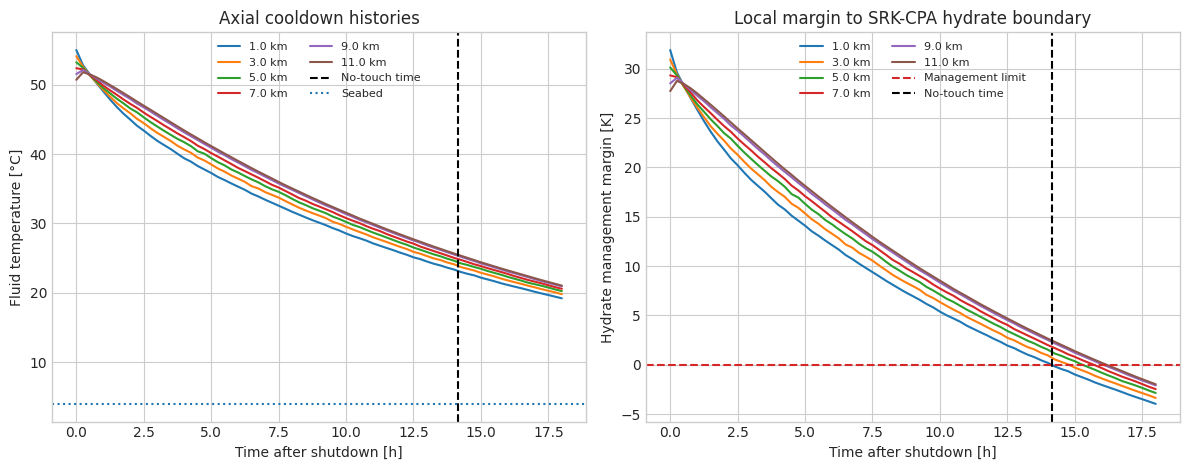

The first zero-margin crossing occurs at **14.14 h**, near **1.0 km**. At the nearest stored time, that cell is **23.0 °C** at **98.7 bara**. This axial minimum—not the mean flowline temperature—is the operational decision point.

In [6]:
coldest = fine_history.loc[fine_history.groupby("time_h")["hydrate_margin_K"].idxmin()].copy()
critical_row = coldest.iloc[np.argmin(np.abs(coldest.time_h - no_touch_h))]
critical_cell = int(critical_row.cell)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for cell in range(CASE["sections"]):
    part = fine_history[fine_history.cell == cell]
    axes[0].plot(part.time_h, part.temperature_C, label=f"{x_m[cell]/1000:.1f} km")
    axes[1].plot(part.time_h, part.hydrate_margin_K, label=f"{x_m[cell]/1000:.1f} km")
axes[0].axvline(no_touch_h, color="k", linestyle="--", label="No-touch time")
axes[0].axhline(CASE["ambient_C"], color="tab:blue", linestyle=":", label="Seabed")
axes[0].set(xlabel="Time after shutdown [h]", ylabel="Fluid temperature [°C]",
            title="Axial cooldown histories")
axes[1].axhline(0.0, color="tab:red", linestyle="--", label="Management limit")
axes[1].axvline(no_touch_h, color="k", linestyle="--", label="No-touch time")
axes[1].set(xlabel="Time after shutdown [h]", ylabel="Hydrate management margin [K]",
            title="Local margin to SRK-CPA hydrate boundary")
axes[0].legend(ncol=2, fontsize=8); axes[1].legend(ncol=2, fontsize=8)
fig.tight_layout(); plt.show()

display(Markdown(
    f"The first zero-margin crossing occurs at **{no_touch_h:.2f} h**, near **{critical_row.x_m/1000:.1f} km**. "
    f"At the nearest stored time, that cell is **{critical_row.temperature_C:.1f} °C** at "
    f"**{critical_row.pressure_bara:.1f} bara**. This axial minimum—not the mean flowline temperature—is the "
    "operational decision point."
))

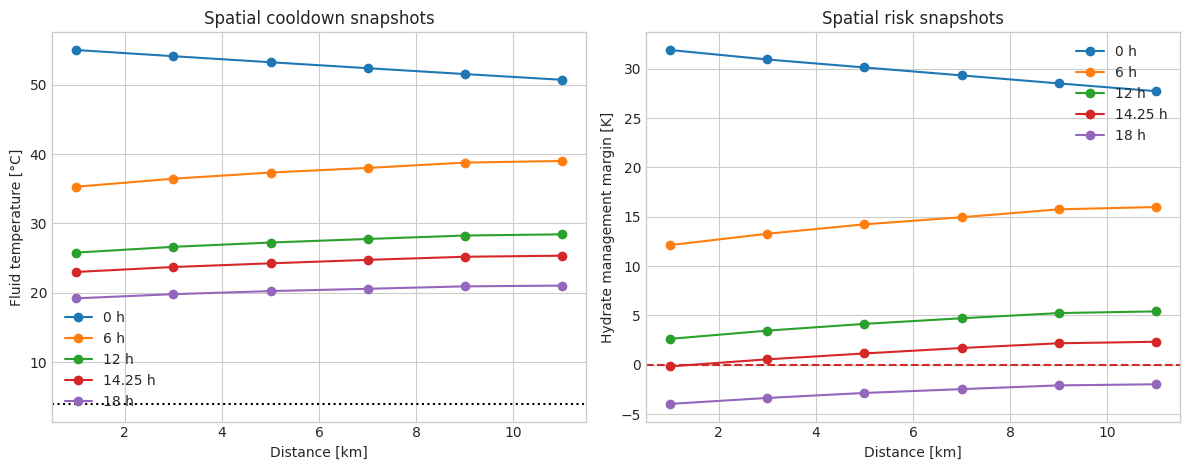

,time_h,x_m,pressure_bara,temperature_C,hydrate_equilibrium_T_K,hydrate_margin_K
342,14.25,1000.0,98.6886,23.015,293.3216,-0.1566


The profiles remain axially non-uniform after close-in because each cell starts with different temperature and phase inventory. The 12 h curve still has positive margin; the curve nearest the interpolated crossing first touches zero at the identified cell.

In [7]:
snapshot_hours = [0.0, 6.0, 12.0, round(no_touch_h / 0.25) * 0.25, 18.0]
snapshot_hours = sorted(set(float(v) for v in snapshot_hours))
snapshots = fine_history[fine_history.time_h.isin(snapshot_hours)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for hour in snapshot_hours:
    part = snapshots[snapshots.time_h == hour]
    axes[0].plot(part.x_m / 1000, part.temperature_C, "o-", label=f"{hour:g} h")
    axes[1].plot(part.x_m / 1000, part.hydrate_margin_K, "o-", label=f"{hour:g} h")
axes[0].axhline(CASE["ambient_C"], color="k", linestyle=":")
axes[0].set(xlabel="Distance [km]", ylabel="Fluid temperature [°C]", title="Spatial cooldown snapshots")
axes[1].axhline(0.0, color="tab:red", linestyle="--")
axes[1].set(xlabel="Distance [km]", ylabel="Hydrate management margin [K]", title="Spatial risk snapshots")
axes[0].legend(); axes[1].legend(); fig.tight_layout(); plt.show()

first_unsafe = fine_history[fine_history.hydrate_margin_K <= 0].sort_values(["time_h", "hydrate_margin_K"]).head(1)
display(first_unsafe[["time_h", "x_m", "pressure_bara", "temperature_C", "hydrate_equilibrium_T_K", "hydrate_margin_K"]].round(4))
display(Markdown(
    "The profiles remain axially non-uniform after close-in because each cell starts with different temperature and "
    "phase inventory. The 12 h curve still has positive margin; the curve nearest the interpolated crossing first "
    "touches zero at the identified cell."
))

## 6. Verification and independent screening

The two-fluid answer is checked against a 30-minute run from a freshly initialized flowing state and the native `SurfCooldownAnalyzer`. The latter is intentionally only a lumped screen: it cannot see terrain, axial gradients, phase redistribution, or local wall states. Agreement in order of magnitude is expected; identity is not.

In [8]:
coarse_started = time.monotonic()
coarse_pipe, coarse_history, coarse_summary, coarse_no_touch_h, _ = run_shutdown(CASE["coarse_dt_s"])
coarse_elapsed_s = time.monotonic() - coarse_started

lumped_fluid = build_fluid(
    temperature_C=float(steady.temperature_C.mean()),
    pressure_bara=float(steady.pressure_bara.mean()),
)
lumped = SurfCooldownAnalyzer(lumped_fluid)
lumped.setInternalDiameter(CASE["diameter_m"])
lumped.setWallThickness(CASE["wall_thickness_m"])
lumped.setInsulationThickness(CASE["insulation_thickness_m"])
lumped.setInsulationConductivity(0.035)
lumped.setCoatingThickness(0.0005)
lumped.setSeabedTemperature(CASE["ambient_C"])
lumped.setOperatingTemperature(float(steady.temperature_C.mean()))
lumped.setHydrateMargin(CASE["hydrate_safety_margin_K"])
lumped.setRequiredNoTouchTimeHours(12.0)
lumped.setTimeStepMinutes(5.0)
lumped.setTotalTimeHours(120.0)
lumped.calculate()
lumped_no_touch_h = float(lumped.getNoTouchTimeHours())

dt_difference_percent = 100.0 * abs(no_touch_h - coarse_no_touch_h) / no_touch_h
mass_drift = float(fine_summary.max_abs_mass_drift.max())
mass_residual = float(fine_summary.max_mass_residual.max())
energy_residual = float(fine_summary.max_energy_residual.max())
largest_upward_minimum_step_C = float(np.max(np.diff(fine_summary.minimum_temperature_C)))
net_mean_cooldown_C = float(
    fine_summary.mean_temperature_C.iloc[0] - fine_summary.mean_temperature_C.iloc[-1]
)
alpha_sum_error = float(np.max(np.abs(
    fine_history[["alpha_gas", "alpha_oil", "alpha_water"]].sum(axis=1) - 1.0
)))

checks = pd.DataFrame([
    ("Three thermodynamic phases", ", ".join(sorted(phase_names)), "gas, oil, aqueous", True),
    ("Fine-step no-touch time", no_touch_h, "8–24 h demonstration range", 8 < no_touch_h < 24),
    ("30 min vs 15 min difference [%]", dt_difference_percent, "< 5", dt_difference_percent < 5),
    ("Maximum relative inventory drift", mass_drift, "< 1e-8", mass_drift < 1e-8),
    ("Maximum mass-balance residual", mass_residual, "< 1e-8", mass_residual < 1e-8),
    ("Maximum thermal-energy residual", energy_residual, "< 1e-8", energy_residual < 1e-8),
    ("Maximum phase-fraction sum error", alpha_sum_error, "< 1e-10", alpha_sum_error < 1e-10),
    ("Net mean cooldown [°C]", net_mean_cooldown_C, "> 15", net_mean_cooldown_C > 15.0),
    ("Minimum fluid temperature [°C]", fine_history.temperature_C.min(), "> seabed − 0.1", fine_history.temperature_C.min() > CASE["ambient_C"] - 0.1),
])
checks.columns = ["check", "value", "limit", "passed"]
display(checks)
assert bool(checks.passed.all()), checks[~checks.passed]
print(
    "Largest one-step rise of the local minimum was "
    f"{largest_upward_minimum_step_C:.3f} °C during closed-pipe pressure/holdup redistribution."
)

comparison = pd.DataFrame({
    "model": ["TwoFluidPipe, 15 min", "TwoFluidPipe, 30 min", "SurfCooldownAnalyzer, lumped"],
    "no_touch_time_h": [no_touch_h, coarse_no_touch_h, lumped_no_touch_h],
    "resolves_axial_state": [True, True, False],
    "resolves_phase_holdup": [True, True, False],
})
display(comparison.round(3))
display(Markdown(
    f"Halving the macro step changes no-touch time by **{dt_difference_percent:.2f}%**. "
    f"The native lumped screen gives **{lumped_no_touch_h:.2f} h** versus **{no_touch_h:.2f} h** for the "
    "axially resolved two-fluid calculation. Conservation gates pass; the numerical result is stable enough for this demonstration."
))

Largest one-step rise of the local minimum was 1.086 °C during closed-pipe pressure/holdup redistribution.


,check,value,limit,passed
0,Three thermodynamic phases,"aqueous, gas, oil","gas, oil, aqueous",True
1,Fine-step no-touch time,14.139157,8–24 h demonstration range,True
2,30 min vs 15 min difference [%],0.078258,< 5,True
3,Maximum relative inventory drift,0.0,< 1e-8,True
4,Maximum mass-balance residual,0.0,< 1e-8,True
5,Maximum thermal-energy residual,0.0,< 1e-8,True
6,Maximum phase-fraction sum error,0.0,< 1e-10,True
7,Net mean cooldown [°C],32.519831,> 15,True
8,Minimum fluid temperature [°C],19.213194,> seabed − 0.1,True


,model,no_touch_time_h,resolves_axial_state,resolves_phase_holdup
0,"TwoFluidPipe, 15 min",14.139,True,True
1,"TwoFluidPipe, 30 min",14.150,True,True
2,"SurfCooldownAnalyzer, lumped",59.695,False,False


Halving the macro step changes no-touch time by **0.08%**. The native lumped screen gives **59.70 h** versus **14.14 h** for the axially resolved two-fluid calculation. Conservation gates pass; the numerical result is stable enough for this demonstration.

## 7. One-way NeqSim → OpenFOAM dead-leg handoff

The tee is placed at the synthetic low point near 4.8 km. The export contains SI-unit time histories at that parent-pipe cell, the complete shutdown initial profile, a flashed phase-property table at the tee, and a manifest with model identity and boundary semantics.

| Quantity | NeqSim source | Suggested CFD use |
|---|---|---|
| $P(t)$ | local two-fluid cell pressure | reference/pressure boundary and density state |
| $T(t)$ | local bulk fluid temperature | parent-pipe inflow or time-varying mixed boundary |
| $\alpha_g,\alpha_o,\alpha_w$ | local phase holdups | phase-fraction boundary/initial condition |
| velocity | final flowing two-fluid state | initialize the CFD velocity field at $t=0$ only |
| $T_{hyd}(t),M(t)$ | SRK-CPA post-processing | CFD cold-spot risk field and reporting threshold |
| phase properties | tee-state SRK-CPA flash | OpenFOAM thermophysical dictionaries or tabulation |

Start with **offline one-way coupling**. Include a short parent-pipe length on both sides of the tee so that the CFD solution develops a physically meaningful exchange flow. Map pressure, temperature, and phase fraction from the two adjacent NeqSim cells onto those two CFD patches. After closure, use pressure-driven/zero-gradient velocity boundaries rather than imposing the coarse one-dimensional cell velocities. If the circumferentially integrated CFD wall heat loss differs materially from the one-dimensional assumption, reduce it to $q'(x,t)$ in W/m and iterate it back through a NeqSim heat-transfer profile. That is the clean path toward partitioned two-way coupling; direct simultaneous co-simulation is unnecessary for the first study.

Packaged CFD handoff: /tmp/openfoam_deadleg_handoff.zip (19,668 bytes)


,patch_name,source_cell,source_x_m,time_s,pressure_Pa,temperature_K,alpha_gas,alpha_oil,alpha_water,hydrate_equilibrium_T_K,hydrate_margin_K
0,parent_upstream,1,3000.0,0.0,9.868856e+06,327.261667,0.506830,0.483504,0.009665,293.321641,30.940026
1,parent_upstream,1,3000.0,900.0,9.868856e+06,325.748762,0.454587,0.532125,0.013288,293.321641,29.427121
2,parent_upstream,1,3000.0,1800.0,9.868856e+06,324.532921,0.459902,0.520101,0.019998,293.321641,28.211280
73,parent_downstream,3,7000.0,0.0,9.642758e+06,325.531151,0.511407,0.474866,0.013726,293.201762,29.329390
74,parent_downstream,3,7000.0,900.0,9.642758e+06,325.351058,0.050000,0.918140,0.031860,293.201762,29.149296
75,parent_downstream,3,7000.0,1800.0,9.642758e+06,324.539738,0.050000,0.913862,0.036138,293.201762,28.337976


,phase,density_kg_m3,dynamic_viscosity_Pa_s,specific_heat_J_kgK,thermal_conductivity_W_mK
0,gas,97.127386,0.000016,2891.120677,0.044674
1,oil,513.051020,0.000113,2614.877857,0.090740
2,aqueous,988.298963,0.000519,3820.035083,0.649411


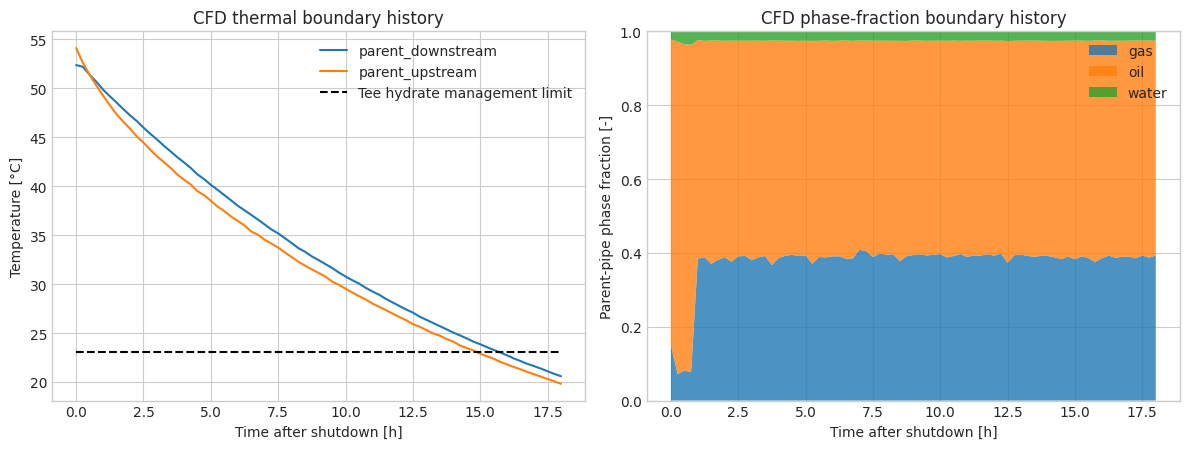

The export uses cell **2 at 5.0 km**, the terrain low point. Row zero preserves the final flowing boundary; later rows describe the closed-parent-pipe state. A local CFD model can now test whether the dead leg becomes colder than the 1D parent cell.

In [9]:
tee_cell = int(np.argmin(np.asarray(CASE["elevation_m"], dtype=float)))
tee_history = fine_history[fine_history.cell == tee_cell].copy()
upstream_cell = max(0, tee_cell - 1)
downstream_cell = min(CASE["sections"] - 1, tee_cell + 1)
boundary_columns = [
    "time_s", "pressure_Pa", "temperature_K", "alpha_gas", "alpha_oil", "alpha_water",
    "hydrate_equilibrium_T_K", "hydrate_margin_K",
]
boundary_frames = []
for patch_name, source_cell in (("parent_upstream", upstream_cell), ("parent_downstream", downstream_cell)):
    frame = fine_history[fine_history.cell == source_cell][boundary_columns].copy()
    frame.insert(0, "source_x_m", float(x_m[source_cell]))
    frame.insert(0, "source_cell", source_cell)
    frame.insert(0, "patch_name", patch_name)
    boundary_frames.append(frame)
boundary = pd.concat(boundary_frames, ignore_index=True)

tee_initial = tee_history.iloc[0]
property_state = build_fluid(
    temperature_C=float(tee_initial.temperature_C),
    pressure_bara=float(tee_initial.pressure_bara),
)
property_rows = []
for i in range(property_state.getNumberOfPhases()):
    phase = property_state.getPhase(i)
    property_rows.append({
        "phase": str(phase.getPhaseTypeName()),
        "density_kg_m3": float(phase.getDensity("kg/m3")),
        "dynamic_viscosity_Pa_s": float(phase.getViscosity("kg/msec")),
        "specific_heat_J_kgK": float(phase.getCp("J/kgK")),
        "thermal_conductivity_W_mK": float(phase.getThermalConductivity("W/mK")),
    })
properties = pd.DataFrame(property_rows)

handoff_dir = Path(os.environ.get("NEQSIM_HANDOFF_DIR", "/tmp/openfoam_deadleg_handoff"))
if handoff_dir.exists():
    shutil.rmtree(handoff_dir)
handoff_dir.mkdir(parents=True, exist_ok=True)
boundary.to_csv(handoff_dir / "parent_pipe_boundaries.csv", index=False)
tee_history.to_csv(handoff_dir / "tee_reference_history.csv", index=False)
fine_history[fine_history.time_s == 0].to_csv(handoff_dir / "flowline_initial_fields.csv", index=False)
properties.to_csv(handoff_dir / "tee_phase_properties.csv", index=False)

manifest = {
    "schema_version": 1,
    "purpose": "offline one-way boundary handoff from NeqSim TwoFluidPipe to a local OpenFOAM tee plus dead-leg model",
    "neqsim": provenance,
    "thermodynamic_model": "SystemSrkCPAstatoil; mixing rule 10; multiphase check enabled",
    "composition_relative_amounts": COMPOSITION,
    "flowline_case": CASE,
    "tee": {"cell": tee_cell, "x_m": float(x_m[tee_cell]), "elevation_m": CASE["elevation_m"][tee_cell]},
    "cfd_parent_patches": {
        "parent_upstream": {"source_cell": upstream_cell, "source_x_m": float(x_m[upstream_cell])},
        "parent_downstream": {"source_cell": downstream_cell, "source_x_m": float(x_m[downstream_cell])},
    },
    "time_convention": "seconds after simultaneous inlet and outlet closure; row 0 is the final flowing state",
    "velocity_mapping": "initialize from the t=0 profile; after closure do not prescribe coarse 1D velocities—use mapped pressure with pressure-driven/zero-gradient CFD velocity patches",
    "phase_fraction_convention": "cell volumetric holdup; alpha_gas + alpha_oil + alpha_water = 1",
    "pressure_convention": "absolute pressure in Pa",
    "temperature_convention": "absolute temperature in K",
    "coupling_scope": "system-scale history only; CFD owns local tee/dead-leg flow and conjugate heat transfer",
    "no_touch_time_h": no_touch_h,
}
(handoff_dir / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
(handoff_dir / "README.md").write_text(
    "# NeqSim to OpenFOAM dead-leg handoff\n\n"
    "Map `parent_pipe_boundaries.csv` onto the upstream and downstream parent-pipe CFD patches. "
    "Use `flowline_initial_fields.csv` to initialize the final flowing state, `tee_reference_history.csv` as a "
    "centreline validation history, and "
    "`tee_phase_properties.csv` to initialize or tabulate phase properties. The CFD geometry "
    "should contain a parent-pipe section, tee, solid pipe/insulation, and capped branch. "
    "Interpolate boundary values conservatively in time and preserve the SI units and sign conventions in `manifest.json`.\n",
    encoding="utf-8",
)

zip_path = handoff_dir.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(handoff_dir.iterdir()):
        archive.write(path, arcname=path.name)

display(boundary.groupby("patch_name").head(3).round(6))
display(properties.round(6))
print(f"Packaged CFD handoff: {zip_path} ({zip_path.stat().st_size:,} bytes)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for patch_name, part in boundary.groupby("patch_name"):
    axes[0].plot(part.time_s / 3600, part.temperature_K - 273.15, label=patch_name)
axes[0].plot(tee_history.time_s / 3600,
             tee_history.hydrate_equilibrium_T_K - 273.15 + CASE["hydrate_safety_margin_K"],
             "k--", label="Tee hydrate management limit")
axes[0].set(xlabel="Time after shutdown [h]", ylabel="Temperature [°C]", title="CFD thermal boundary history")
axes[0].legend()
axes[1].stackplot(tee_history.time_s / 3600, tee_history.alpha_gas, tee_history.alpha_oil, tee_history.alpha_water,
                  labels=["gas", "oil", "water"], alpha=0.8)
axes[1].set(xlabel="Time after shutdown [h]", ylabel="Parent-pipe phase fraction [-]", ylim=(0, 1),
            title="CFD phase-fraction boundary history")
axes[1].legend(loc="upper right")
fig.tight_layout(); plt.show()
display(Markdown(
    f"The export uses cell **{tee_cell} at {x_m[tee_cell]/1000:.1f} km**, the terrain low point. "
    "Row zero preserves the final flowing boundary; later rows describe the closed-parent-pipe state. "
    "A local CFD model can now test whether the dead leg becomes colder than the 1D parent cell."
))

## 8. Interpretation, limitations, and next CFD notebook

For this synthetic case, the output above is the actionable answer: the earliest axial hydrate-management margin controls, while the lumped mean-temperature answer is only a screen. The generated handoff makes the model boundary explicit and avoids duplicating the complete 12 km flowline in CFD.

Important limitations:

- `TwoFluidPipe` is used here with conservative closed-boundary thermal physics, but the long-duration gas–oil–water shutdown envelope remains an evolving NeqSim capability; track [equinor/neqsim#2907](https://github.com/equinor/neqsim/issues/2907).
- Phase mass transfer and component transport are disabled in the demonstration transient to isolate thermal cooldown and make the example fast. A qualification study should enable and validate condensation/evaporation, composition transport, inhibitor/salinity, and latent heat for the actual fluid.
- Hydrate equilibrium plus 3 K is a management boundary, not hydrate kinetics, agglomeration, deposition, blockage, or restart deliverability.
- Six axial cells are sufficient for the teaching case and time-step check, not for design-grid convergence. Refine geometry and time steps together.
- The 50 W/(m² K) stagnant-side coefficient is an explicit assumption and API-order workaround; [equinor/neqsim#2977](https://github.com/equinor/neqsim/issues/2977) tracks separation of closed-flow inner HTC from the radial overall U-value. Natural convection, stratification, wax/scale, burial, marine growth, and insulation condition require asset data and sensitivity analysis.
- OpenFOAM solver, turbulence/laminar treatment, interface method, contact angle, wall layers, mesh, and conjugate heat-transfer strategy must be selected and verified in the dedicated dead-leg notebook.

### Recommended next implementation

Build a tee plus capped branch with solid steel and insulation regions; map the exported NeqSim histories onto a short parent-pipe section; run mesh, time-step, energy, and phase-volume closure checks; calculate the minimum local fluid/wall temperature and hydrate-margin volume; then compare the area-integrated parent-pipe heat loss with the NeqSim cell. Only introduce iterative two-way coupling if that comparison is materially different.

In [10]:
result_summary = {
    "neqsim_commit": source_commit,
    "steady_runtime_s": steady_elapsed_s,
    "fine_shutdown_runtime_s": fine_elapsed_s,
    "coarse_shutdown_runtime_s": coarse_elapsed_s,
    "fine_no_touch_time_h": no_touch_h,
    "coarse_no_touch_time_h": coarse_no_touch_h,
    "time_step_difference_percent": dt_difference_percent,
    "lumped_no_touch_time_h": lumped_no_touch_h,
    "critical_cell": critical_cell,
    "critical_position_km": float(critical_row.x_m / 1000.0),
    "radial_overall_U_W_m2K_inner_basis": radial_overall_U,
    "max_relative_mass_drift": mass_drift,
    "max_mass_balance_relative_residual": mass_residual,
    "max_thermal_energy_relative_residual": energy_residual,
    "handoff_zip": str(zip_path),
}
print(json.dumps(result_summary, indent=2))
assert zip_path.is_file() and zip_path.stat().st_size > 1000
print("PASS — executed three-phase cooldown demonstration and OpenFOAM handoff package")

{
  "neqsim_commit": "879eeded80135ad485de4327907fe6c3282cba08",
  "steady_runtime_s": 1.7789826870002798,
  "fine_shutdown_runtime_s": 10.585701490999782,
  "coarse_shutdown_runtime_s": 8.898501984999712,
  "fine_no_touch_time_h": 14.139156799240137,
  "coarse_no_touch_time_h": 14.150221841944923,
  "time_step_difference_percent": 0.07825815118890588,
  "lumped_no_touch_time_h": 59.69513036057004,
  "critical_cell": 0,
  "critical_position_km": 1.0,
  "radial_overall_U_W_m2K_inner_basis": 0.7773780807850504,
  "max_relative_mass_drift": 3.0658144456950823e-15,
  "max_mass_balance_relative_residual": 1.1996665222285128e-15,
  "max_thermal_energy_relative_residual": 1.2379960801483927e-12,
  "handoff_zip": "/tmp/openfoam_deadleg_handoff.zip"
}
PASS — executed three-phase cooldown demonstration and OpenFOAM handoff package
